# Customer churn prediction using Logistic Regression

In [3]:
import pandas as pd

data = {
    "tenure": [1, 5, 10, 12, 24, 36, 48],
    "monthly_charges": [20, 30, 45, 50, 70, 80, 90],
    "support_calls": [3, 1, 0, 2, 1, 0, 0],
    "churn": ["yes", "no", "no", "yes", "no", "no", "no"]
}

df = pd.DataFrame(data)

df

,tenure,monthly_charges,support_calls,churn
0,1,20,3,yes
1,5,30,1,no
2,10,45,0,no
3,12,50,2,yes
4,24,70,1,no
5,36,80,0,no
6,48,90,0,no


In [4]:
os.listdir("Desktop/")

['desktop.ini', 'Jupyter Notebook.lnk', 'RStudio.lnk']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   tenure           7 non-null      int64 
 1   monthly_charges  7 non-null      int64 
 2   support_calls    7 non-null      int64 
 3   churn            7 non-null      object
dtypes: int64(3), object(1)
memory usage: 356.0+ bytes


In [6]:
df["churn"] = df["churn"].map({"yes": 1, "no": 0})
df

,tenure,monthly_charges,support_calls,churn
0,1,20,3,1
1,5,30,1,0
2,10,45,0,0
3,12,50,2,1
4,24,70,1,0
5,36,80,0,0
6,48,90,0,0


In [7]:
X = df[["tenure", "monthly_charges", "support_calls"]]
y = df["churn"]

X, y

(   tenure  monthly_charges  support_calls
 0       1               20              3
 1       5               30              1
 2      10               45              0
 3      12               50              2
 4      24               70              1
 5      36               80              0
 6      48               90              0,
 0    1
 1    0
 2    0
 3    1
 4    0
 5    0
 6    0
 Name: churn, dtype: int64)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train

,tenure,monthly_charges,support_calls
2,10,45,0
4,24,70,1
3,12,50,2
6,48,90,0


In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [10]:
y_pred = model.predict(X_test)

y_pred

array([1, 1, 0])

In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



## Customer Churn Prediction

This notebook builds a simple logistic regression model to predict whether a customer will churn.

Features used:
- tenure
- monthly_charges
- support_calls

Steps:
1. Prepare the dataset
2. Convert churn labels to numeric values
3. Split data into training and testing sets
4. Train a logistic regression model
5. Evaluate model performance using classification metrics

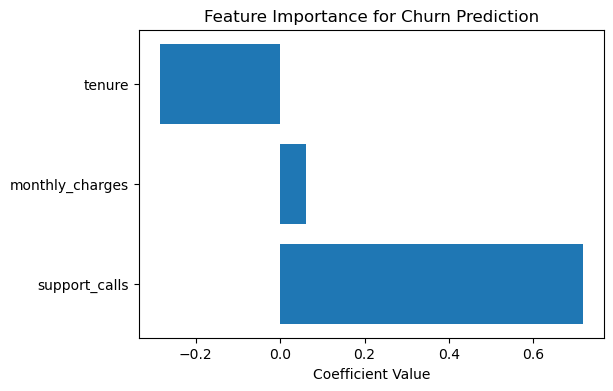

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract coefficients
coefficients = model.coef_[0]

# Feature names
features = X.columns

# Create dataframe
importance = pd.DataFrame({
    "Feature": features,
    "Importance": coefficients
})

# Sort by importance
importance = importance.sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(6,4))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Coefficient Value")
plt.title("Feature Importance for Churn Prediction")
plt.show()


### Interpretation

The model suggests that the number of support calls is the strongest predictor of churn. 
Customers who contact support frequently are more likely to leave the service.

Tenure has a negative coefficient, indicating that long-term customers are less likely to churn.

Monthly charges show a small positive effect on churn.